In [1]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

ugent_blue = (30/255, 100/255, 200/255)

In [ ]:
from src.datasets import NetworksDataset
from src.automata import LLNA
from src.simulation import *
from src.analysis import jacobian, defect_diameter, calculate_Yt, lyapunov_spectrum

%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'datasets'

# Static Networks

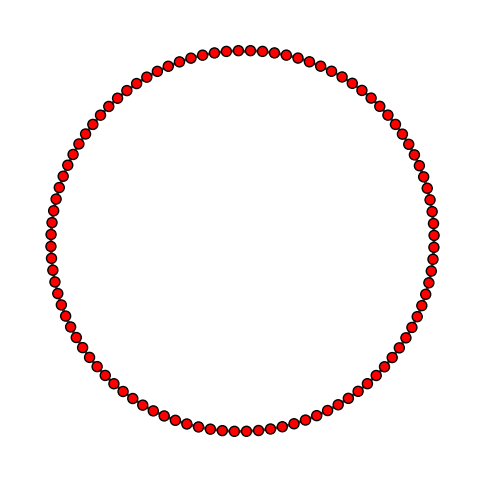

In [5]:
# a regular, connected network

SAVEFIG = False

N = 100
G = ig.Graph.K_Regular(N, 2)
while not G.is_connected():
    G = ig.Graph.K_Regular(N, 2)
G.vs["color"] = ['red' for _ in range(N)] # [ugent_blue for _ in range(N)]

vertex_size=10
fig, ax = plt.subplots(1,1,figsize=(6,6))
ig.plot(G, target=ax, vertex_size=vertex_size)

if SAVEFIG:
    plt.savefig(f"figures/regular_network_N={N}_vs={vertex_size}.pdf", bbox_inches='tight')

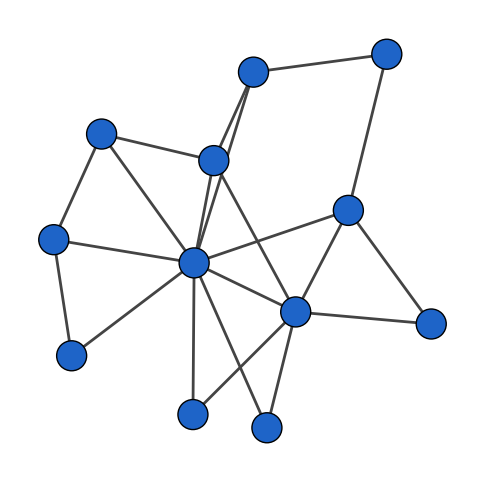

In [5]:
# a B-A network

SAVEFIG = False

N = 12
min_edges=2
G = ig.Graph.Barabasi(N, min_edges)
while not G.is_connected():
    G = ig.Graph.Barabasi(N, min_edges)
G.vs["color"] = [ugent_blue for _ in range(N)]

vertex_size=30
fig, ax = plt.subplots(1,1,figsize=(6,6))
ig.plot(G, target=ax, vertex_size=vertex_size)

if SAVEFIG:
    plt.savefig(f"figures/barabasi_network_N={N}_vs={vertex_size}.pdf", bbox_inches='tight')

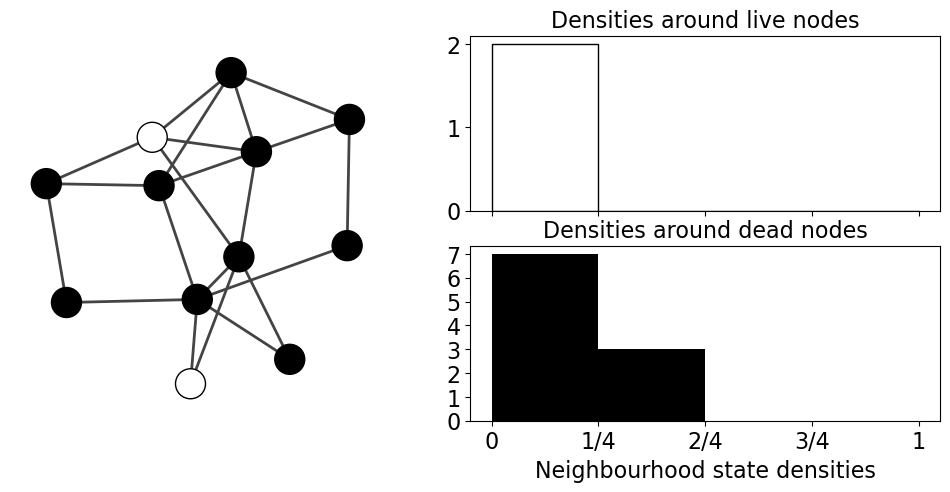

In [6]:
# a B-A network

SAVEFIG = False

N = 12
min_edges=2
G = ig.Graph.Barabasi(N, min_edges)
while not G.is_connected():
    G = ig.Graph.Barabasi(N, min_edges)

G.vs["state"] = np.random.randint(2,size=N)
G.vs["color"] = np.array(G.vs["state"])*255 # white is 255

vertex_size=30

# Create a figure with gridspec to control the layout
fig = plt.figure(figsize=(12, 5))
grid = fig.add_gridspec(2, 2, width_ratios=[4, 5], height_ratios=[1, 1])

# Large plot on the left, spanning both rows
ax1 = fig.add_subplot(grid[:, 0])  # This takes both rows on the left
ax2 = fig.add_subplot(grid[0, 1])  # Upper right
ax3 = fig.add_subplot(grid[1, 1], sharex=ax2)  # Lower right

# Remove x-axis labels from ax2 to avoid duplication
plt.setp(ax2.get_xticklabels(), visible=False)

ig.plot(G, target=ax1, vertex_size=vertex_size)

dead_rhos = []
live_rhos = []
for v in range(N):
    neighbors = G.neighbors(v)
    nbh_size = len(neighbors)
    neighbor_rho = sum(G.vs[neighbor]["state"] for neighbor in neighbors)/nbh_size
    if G.vs["state"][v] == 1: # alive
        live_rhos.append(neighbor_rho)
    else:
        dead_rhos.append(neighbor_rho)

bins=np.linspace(0,1,5)
labelsize=16

quants = ax2.hist(live_rhos, color='white', edgecolor='k', bins=bins)[0]
ax2.set_yticks(np.arange(0, max(quants)+1, 1))
ax2.set_xticks(bins)
ax2.set_xlim([-0.05,1.05])
ax2.tick_params(axis='y', labelsize=labelsize)
ax2.set_title("Densities around live nodes", fontsize=labelsize)

quants = ax3.hist(dead_rhos, color='black', bins=bins)[0]
ax3.set_yticks(np.arange(0, max(quants)+1, 1))
ax3.set_xticks(bins)
ax3.set_xticklabels(['0', '1/4', '2/4', '3/4', '1'])
ax3.set_xlim([-.05,1.05])
ax3.set_xlabel("Neighbourhood state densities", fontsize=labelsize)
ax3.tick_params(axis='both', labelsize=labelsize)
ax3.set_title("Densities around dead nodes", fontsize=labelsize)

if SAVEFIG:
    plt.savefig(f"figures/example_rhos_barabasi_N={N}.pdf", bbox_inches='tight')

# Animation of LLNA

In [23]:
def step_inspector(matrices:dict):
    for name in ['h', 'p', 'b', 's']:
        M = np.array(matrices[name]).round(decimals=2)
        print(f'{name}:', M.shape, M)
    print('-'*40)

def plot_params(graph, labels=False):
    import math
    params = {
        'vertex_color': np.array(graph.vs["states"])*255,
        # 'edge_color': 125,
        'vertex_size': 30
    }
    if labels:
        params.update({
            'vertex_label': graph.vs["name"],
            'vertex_label_color': 'blue',
            'vertex_label_size': 10,
            'vertex_label_dist': 1.5,
            'vertex_label_angle': math.pi/4
        })
    return params

In [27]:
N = 12
min_edges=2
G = ig.Graph.Barabasi(N, min_edges)
while not G.is_connected():
    G = ig.Graph.Barabasi(N, min_edges)

# G.vs["states"] = np.random.randint(2,size=N)
# G.vs["colors"] = np.array(G.vs["states"])*255 # white is 255

G.to_directed()
edges = tc.tensor(G.get_edgelist()).T
G.to_undirected()

Some interesting rules:
- R=4:B12_S13
- R=4:B1_S013
- R=4:B123_S013

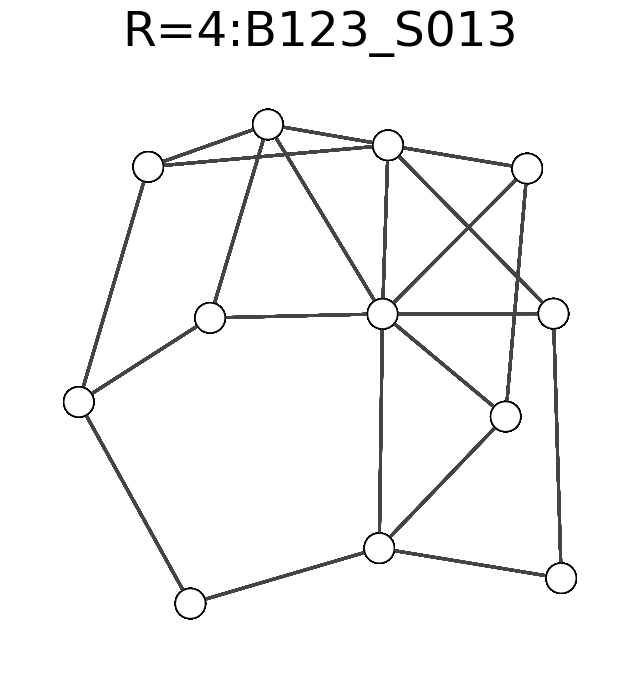

In [50]:
# a simple LLNA
resolution = 4
T = 32
model = LLNA(resolution)# [1,2], y=[1,3]) # takes the LLNA from the example
rule = str(model)

# random initial condition
s0 = np.random.randint(2, size=N).astype(float)

# open figure
fig, ax = plt.subplots(1,1,figsize=(8,8))
size=10

# G.vs["states"] = s0
# ig.plot(G, target=ax, **plot_params(G))
# plt.savefig(f"figures/LLNA_{''.join(rule.split(':'))}_t=00.png", bbox_inches='tight')

st = tc.tensor(s0)[None,:]
for t in range(T):
    # assign to state property of graph
    # turn configuration into tc tensor and add extra dimension for number of samples
    # evolve over one time step
    st = model.step(edges, st)
    G.vs["states"] = np.array(st[0])
    ig.plot(G, target=ax, **plot_params(G))
    ax.set_title(rule, fontsize=35)
    t_padded = str(t)
    if t < 10:
        t_padded = '0'+t_padded
    plt.savefig(f"figures/LLNA_{''.join(rule.split(':'))}_t={t_padded}.png", bbox_inches='tight')

# visualise defects

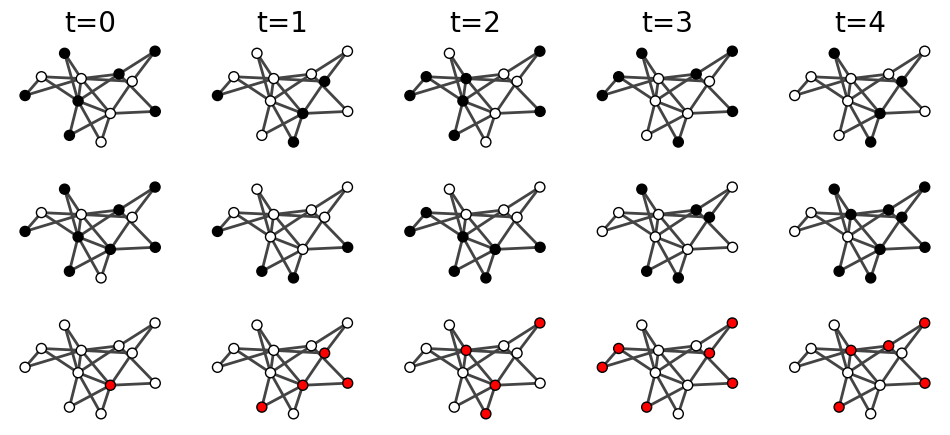

In [17]:
SAVEFIG=True

N = 12
min_edges=2
G = ig.Graph.Barabasi(N, min_edges)
while not G.is_connected():
    G = ig.Graph.Barabasi(N, min_edges)

# G.vs["states"] = np.random.randint(2,size=N)
# G.vs["colors"] = np.array(G.vs["states"])*255 # white is 255

G.to_directed()
edges = tc.tensor(G.get_edgelist()).T
G.to_undirected()

T = 5
resolution = 4
model = LLNA(resolution, x=[1,2], y=[1,3])
rule = str(model)

# imposed defect in a particular node
defect_pos = 0
delta_x0 = np.zeros(N, dtype=int)
delta_x0[defect_pos] = 1

# initial configuration
states = np.random.randint(2,size=N)

# allocate all T-1 Jacobians
Js = np.zeros(shape=(T-1,N,N), dtype=int)
# all states (will be updated in the loop)
states_original = np.tile(states, (T,1))
states_perturbed = np.tile((states+delta_x0)%2, (T,1))
deltas = np.tile(delta_x0, (T,1))

# iterate original NA, perturbed NA, and the defect itself over T time steps
for t in range(1,T):
    # calculate next time step (from unperturbed initial configuration)
    states_original[t] = np.array(model.step(edges, tc.tensor(states_original[t-1])))
    # calculate next time step (from perturbed initial configuration)
    states_perturbed[t] = np.array(model.step(edges, tc.tensor(states_perturbed[t-1])))
    # calculate difference
    deltas[t] = np.abs(states_original[t] - states_perturbed[t])

fig, axs = plt.subplots(3,T,figsize=(12,5))
size=20

for row in range(3):
    colors = [states_original, states_perturbed, deltas][row]
    for t, ax in enumerate(axs[row,:]):
        if row == 2:
            vertex_color = [(1, 1-colors[t,v], 1-colors[t,v]) for v in range(N)]
        else:
            vertex_color = colors[t]*255
        ig.plot(G, target=ax, vertex_color=vertex_color, vertex_size=10)
        if row == 0:
            ax.set_title(f"t={t}", size=size)

if SAVEFIG:
    plt.savefig(f"figures/defect_propagation-{''.join(rule.split(':'))}.pdf", bbox_inches='tight')
# _=fig.suptitle(f"Subsequent states for rule {rule}, from original (top) and defected (bottom) configuration.")